# Logistic Regression as a Single Neuron
---
## Step 1 — Linear vs Affine Maps

### Motivation

Understanding the difference between **linear** and **affine** maps is fundamental in machine learning.  
Most models — including logistic regression and neural networks — are built from affine transformations followed by nonlinear activation functions.

This notebook connects:

- Linear maps
- Affine maps
- Logistic regression
- A single artificial neuron

---

### Linear Maps

A linear map is a transformation that satisfies two properties:

1. **Additivity**
   $$
   f(x + y) = f(x) + f(y)
   $$

2. **Homogeneity**
   $$
   f(\alpha x) = \alpha f(x)
   $$

From these properties, it necessarily follows that:

$$
f(0) = 0
$$

So a linear map always keeps the origin fixed.

In matrix form:

$$
f(x) = Wx
$$

Geometrically, linear maps can:
- Scale
- Rotate
- Shear

But they cannot shift the space.

---

### Affine Maps

An affine map extends a linear map by adding a translation term:

$$
f(x) = Wx + b
$$

Where:
- W is the linear transformation
- b is the bias (translation)

Unlike linear maps:

$$
f(0) = b
$$

So the origin is shifted.

An affine map is composed of:
- A **linear part**
- A **translation (bias) part**

Every linear map is a special case of an affine map where $$b = 0$$.

---

### Logistic Regression as a Single Neuron

Logistic regression computes:

$$
z = w^T x + b
$$
$$
\hat{y} = \sigma(z)
$$

Where:
- $ w^T x + b $ is an affine transformation
- $ \sigma(z) $ is the sigmoid activation function

This structure is identical to a single artificial neuron:

1. Compute weighted sum (affine transformation)
2. Apply activation function

Therefore, logistic regression can be understood as a **single neuron with a sigmoid activation function**.

---

### Code Example: Linear vs Affine Transformation

Now that we have introduced the theoretical definitions of linear and affine maps, 
we will implement both transformations using NumPy.

Our goal is to translate the mathematical expressions:

$$
f(x) = Wx
$$

and

$$
f(x) = Wx + b
$$

into code.

In this example:

- $W$ will be a 2×2 matrix representing the linear transformation.
- $x$ will be a 2-dimensional input vector.
- $b$ will be a 2-dimensional bias vector.

We will compute:

1. The linear transformation $Wx$
2. The affine transformation $Wx + b$

Finally, we will evaluate both transformations when the input vector is the zero vector.  
This allows us to clearly observe the defining difference:

- A linear map always maps the origin to zero.
- An affine map shifts the origin by the bias term.

In [93]:
import numpy as np
rng = np.random.default_rng(42)

def linear_transformation(inputs, weights): return weights @ inputs
def affine_transformation(inputs, weights, bias): return (weights @ inputs) + bias

weights = rng.normal(loc=0, scale=1, size=(2, 2))
inputs = rng.integers(low=0, high=100, size=2)
bias = rng.integers(low=10, high=15, size=2)

print('For inputs ', inputs, ' we have the linear transformation result is', linear_transformation(inputs, weights))
print('For inputs ', inputs, ' we have the affine transformation result is', affine_transformation(inputs, weights, bias))
print('\n')

zero_inputs = np.zeros(2)
print('For inputs ', zero_inputs, ' we have the linear transformation result is', linear_transformation(zero_inputs, weights))
print('For inputs ', zero_inputs, ' we have the affine transformation result is', affine_transformation(zero_inputs, weights, bias), 
    ', where the bias is ', bias)


For inputs  [20  9]  we have the linear transformation result is [-3.26551536 23.47410636]
For inputs  [20  9]  we have the affine transformation result is [ 8.73448464 37.47410636]


For inputs  [0. 0.]  we have the linear transformation result is [0. 0.]
For inputs  [0. 0.]  we have the affine transformation result is [12. 14.] , where the bias is  [12 14]


## Step 2 — Build a Single Neuron (Forward Pass Only)
### Implementing and Visualizing the Sigmoid Function

The sigmoid function plays a central role in logistic regression and neural networks.  
It transforms a real-valued input into a value between 0 and 1, allowing us to interpret the output as a probability.

Mathematically, the sigmoid function is defined as:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

#### Key Properties

- Its output range is (0, 1)
- $\sigma(0) = 0.5$
- As $z \to +\infty$, $\sigma(z) \to 1$
- As $z \to -\infty$, $\sigma(z) \to 0$

In logistic regression, the affine transformation

$$
z = w^T x + b
$$

is passed through the sigmoid function to produce a probability estimate.

In the following code, we:

1. Implement the sigmoid function using NumPy.
2. Generate a range of input values.
3. Plot the sigmoid curve to visualize its behavior.


Text(0.5, 1.0, 'Sigmoid Function')

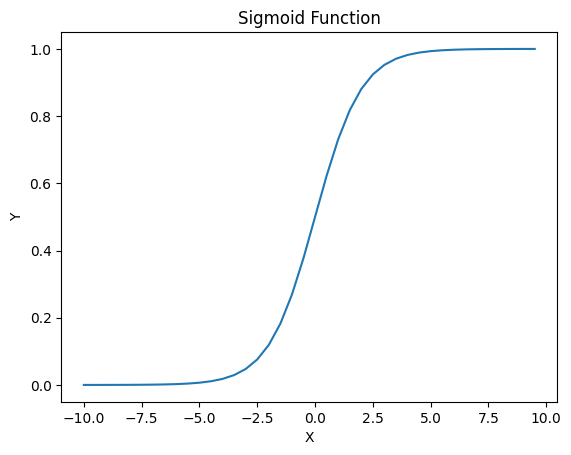

In [94]:
from numpy.typing import ArrayLike
import matplotlib.pyplot as plt

def sigmoid(z: ArrayLike):
    return 1 / (1 + np.exp(-z))

inputs = np.arange(-10, 10, step=.5)
y = sigmoid(inputs)

plt.plot(inputs, y)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Sigmoid Function')

## Logistic Regression as a Single Neuron

A single artificial neuron performs two operations:

1. Compute an affine transformation
2. Apply a nonlinear activation function

Mathematically:

$$
z = w^T x + b
$$

$$
a = \sigma(z)
$$

Where:

- $w$ is the weight vector
- $b$ is the bias term
- $z$ is the pre-activation value
- $\sigma(z)$ is the sigmoid activation function
- $a$ is the predicted probability

### Geometric Interpretation

The expression

$$
w^T x + b = 0
$$

defines a hyperplane (decision boundary).

The value

$$
z = w^T x + b
$$

represents the **signed distance** (up to scaling) from that boundary:

- \( z > 0 \) → point lies on one side
- \( z < 0 \) → point lies on the other side
- \( z = 0 \) → point lies exactly on the boundary

The sigmoid function transforms this signed distance into a probability between 0 and 1.

Therefore, logistic regression is mathematically equivalent to a single neuron with a sigmoid activation function.


In [95]:

def neuron_forward(x, w, b):
    affine_transformation = (w @ x) + b
    return sigmoid(affine_transformation) 

w = np.array([1, 1])
x = np.array([2, -2])
b = 0

neuron_forward(x, w, b)

np.float64(0.5)

### Linear Regression Example

Text(0.5, 1.0, 'Binary Cross-Entropy Loss During Training')

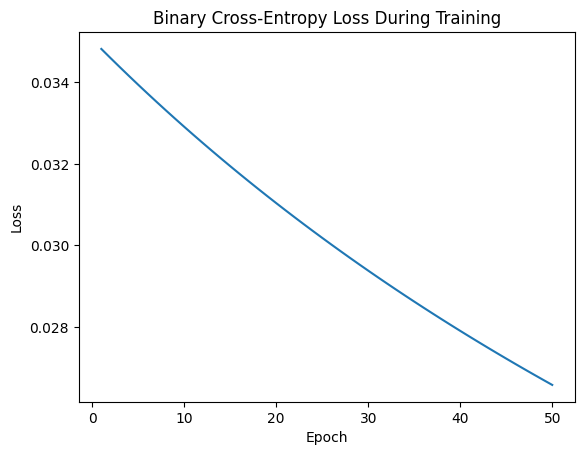

In [ ]:
def logistic_regression(X, w, b):
    z = X @ w + b
    return sigmoid(z)

def gradient(X: Array, y_true: Array, y_pred: Array):
    dL_dw = (X.T @ (y_pred - y_true)) / len(y_pred)
    db_dw = np.mean(y_pred - y_true)
    return dL_dw, db_dw

# Loss function
def binary_cross_entropy(y_true: Array, y_pred: Array):
    # Adjustment terme so the code does not break when L=0
    epsilon = 1e-8
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)

    L = - (y_true*np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return np.mean(L)

def train_logistic_regression(X: Array, y:Array, epochs=50, learning_rate=.05):
    loss = np.zeros(epochs)
    w = np.ones(X.shape[1])
    b = 0

    for i in range(epochs):
        y_pred = logistic_regression(X, w, b)
       
        dL_dw, db_dw = gradient(X, y, y_pred)
        w -= dL_dw * learning_rate
        b -= db_dw * learning_rate

        loss[i] = binary_cross_entropy(y, y_pred)
        
    return w, b, loss

# Samples with a clear decision boundary (0)
x_neg = rng.normal(loc=(-2, -2), scale=1, size=(50, 2))
x_pos = rng.normal(loc=(2, 2), scale=1, size=(50, 2))
x = np.vstack((x_neg, x_pos))

# Labels
y = np.concatenate((np.zeros(50), np.ones(50)))

w, b, loss = train_logistic_regression(x, y)

plt.plot(np.array(range(len(loss)))  + 1, loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Binary Cross-Entropy Loss During Training')